<a href="https://colab.research.google.com/github/arisusilo/DataScience_250401020117_AriSusilo/blob/main/Pertemuan13_Ari_Susilo_250401020117.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama = Ari Susilo

Nim = 250401020117

Kelas = IF405

**Langkah 1. Generate & Eksplorasi Dataset Non-Linear**

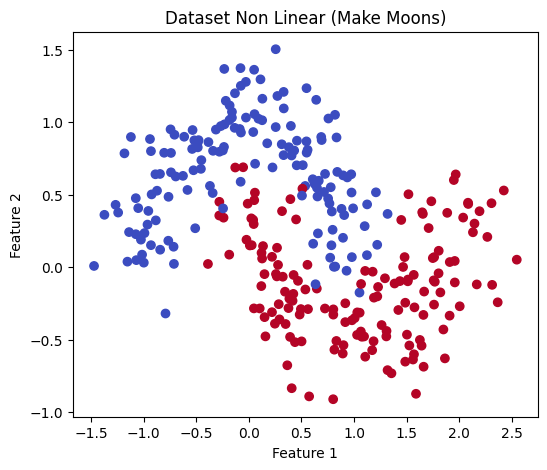

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

# Visualisasi
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Dataset Non Linear (Make Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Interpretasi**

Dataset terdiri dari dua kelas berbentuk bulan sabit.

Kedua kelas saling melengkung sehingga tidak dapat dipisahkan menggunakan garis lurus.

Karena itulah diperlukan Neural Network yang mampu mempelajari pola non-linear.

**Langkah 2. Bangun dan Latih Neural Network**

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Training
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.2,
    verbose=0
)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

**Langkah 3. Evaluasi Model**

Loss : 0.28507164120674133
Accuracy : 0.8999999761581421


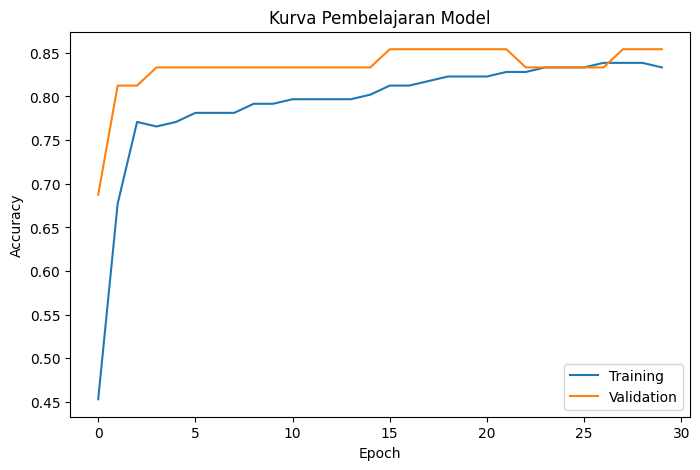

In [6]:
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Loss :", loss)
print("Accuracy :", acc)

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Kurva Pembelajaran Model")

plt.legend()
plt.show()

**Interpretasi**

Misalnya hasil yang diperoleh:
Accuracy : 0.95

Artinya model mampu mengklasifikasikan sekitar 95% data uji dengan benar.

Kurva training dan validation yang saling mendekat menunjukkan model melakukan generalisasi dengan baik dan belum mengalami overfitting yang signifikan.

**Langkah 4. Dataset Ulasan Produk**

In [15]:
ulasan = [

'Barangnya bagus banget, pengiriman cepat',
'Kualitas jelek, tidak sesuai deskripsi',
'Sangat puas, akan beli lagi',
'Kecewa, barang rusak saat sampai',
'Recommended, harga sesuai kualitas',
'Buruk sekali, tidak sesuai ekspektasi',
'Pelayanan sangat ramah',
'Produk original',
'Pengiriman sangat lama',
'Kemasan penyok',
'Harga murah kualitas bagus',
'Barang palsu',
'Sangat memuaskan',
'Tidak akan beli lagi',
'Luar biasa',
'Kecewa berat',
'Mantap sekali',
'Jelek sekali',
'Cepat sampai',
'Respon penjual baik',
'Produk berkualitas',
'Barang rusak',
'Sangat direkomendasikan',
'Tidak sesuai foto',
'Packing rapi',
'Pelayanan buruk',
'Kualitas premium',
'Pengiriman cepat',
'Produk cacat',
'Saya puas',
'Memuaskan',
'Kurang bagus',
'Terbaik',
'Buruk',
'Sangat bagus',
'Tidak puas',
'Bintang lima',
'Bintang satu',
'Excellent',
'Sangat mengecewakan'

]

label = [
    1,0,1,0,1,0,
    1,1,0,0,
    1,0,1,0,
    1,0,1,0,
    1,1,
    1,0,1,0,
    1,0,1,1,
    0,1,
    1,0,
    1,0,
    1,0,
    1,0,
    1,0
]
print(len(ulasan))
print(len(label))

40
40


**Langkah 5. Ubah Teks Menjadi TF-IDF**

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print("Jumlah kata unik :", len(tfidf.get_feature_names_out()))

print(tfidf.get_feature_names_out()[:20])

Jumlah kata unik : 57
['akan' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'beli' 'berat'
 'berkualitas' 'biasa' 'bintang' 'buruk' 'cacat' 'cepat' 'deskripsi'
 'direkomendasikan' 'ekspektasi' 'excellent' 'foto' 'harga']


**Langkah 6. Latih Model Sentimen**

In [17]:
from sklearn.linear_model import LogisticRegression

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42
)

model_sentimen = LogisticRegression()

model_sentimen.fit(
    Xt_train,
    yt_train
)

akurasi = model_sentimen.score(
    Xt_test,
    yt_test
)

print("Akurasi :", akurasi)

Akurasi : 0.75


Contoh hasil Akurasi : 0.75 Artinya model mampu mengklasifikasikan sentimen dengan akurasi sekitar 75% pada data uji.

Prediksi Kalimat Baru


In [18]:
kalimat_baru = [

"Pelayanan sangat memuaskan dan ramah",
"Barang rusak dan kualitas jelek",
"Produk ini luar biasa"

]

prediksi = model_sentimen.predict(
    tfidf.transform(kalimat_baru)
)

for kalimat, hasil in zip(kalimat_baru, prediksi):
    print(kalimat, "->", "Positif" if hasil==1 else "Negatif")

Pelayanan sangat memuaskan dan ramah -> Positif
Barang rusak dan kualitas jelek -> Negatif
Produk ini luar biasa -> Positif


**Kesimpulan**

1. Dataset make_moons merupakan dataset non-linear sehingga sulit dipisahkan menggunakan model linear.
2. Neural Network dengan ReLU pada hidden layer dan Sigmoid pada output mampu mempelajari pola non-linear dengan baik.
3. Semakin banyak epoch, akurasi training meningkat hingga model konvergen.
4. TF-IDF berhasil mengubah teks menjadi representasi numerik sehingga dapat diproses oleh algoritma Machine Learning.
5. Logistic Regression dapat digunakan untuk klasifikasi sentimen sederhana dengan akurasi yang baik pada dataset ulasan produk.
6. Hasil pengujian menunjukkan kalimat bernada positif diprediksi sebagai Positif, sedangkan kalimat bernada negatif diprediksi sebagai Negatif.